In [1]:
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

In [2]:
# ------------------------------------------------------------
# Part 1: First-order Markov chain (satisfies Markov property)
# ------------------------------------------------------------
states = ['Sunny', 'Cloudy', 'Rainy']
n_states = len(states)

# Transition matrix P(s' | s)
# Rows: current state, Columns: next state
# Order: Sunny, Cloudy, Rainy
P = np.array([
    [0.6, 0.3, 0.1],   # from Sunny
    [0.4, 0.4, 0.2],   # from Cloudy
    [0.2, 0.3, 0.5]    # from Rainy
])

def generate_markov_chain(P, initial_state=0, n_steps=20):
    """Generate a sequence of states from a first-order Markov chain."""
    seq = [initial_state]
    for _ in range(n_steps - 1):
        prob = P[seq[-1]]
        next_state = np.random.choice(n_states, p=prob)
        seq.append(next_state)
    return seq

In [3]:
# ------------------------------------------------------------
# Part 2: Second-order chain (violates Markov property if treated as first-order)
# ------------------------------------------------------------
# Transition probabilities depend on the last TWO states.
# We'll define a mapping from (prev, current) -> next distribution.
# States still 0,1,2.

second_order = {}
# Example: after (Sunny, Sunny) -> 70% Sunny, 20% Cloudy, 10% Rainy
second_order[(0,0)] = [0.7, 0.2, 0.1]
second_order[(0,1)] = [0.5, 0.3, 0.2]
second_order[(0,2)] = [0.4, 0.4, 0.2]
second_order[(1,0)] = [0.3, 0.5, 0.2]
second_order[(1,1)] = [0.2, 0.6, 0.2]
second_order[(1,2)] = [0.2, 0.3, 0.5]
second_order[(2,0)] = [0.1, 0.2, 0.7]
second_order[(2,1)] = [0.2, 0.3, 0.5]
second_order[(2,2)] = [0.1, 0.2, 0.7]

In [4]:
def generate_second_order(initial_pair=(0,0), n_steps=20):
    """Generate sequence where next state depends on last two states."""
    seq = [initial_pair[0], initial_pair[1]]
    for _ in range(n_steps - 2):
        prev, curr = seq[-2], seq[-1]
        prob = second_order[(prev, curr)]
        next_state = np.random.choice(n_states, p=prob)
        seq.append(next_state)
    return seq

Theoretical transition matrix (first-order):
[[0.6 0.3 0.1]
 [0.4 0.4 0.2]
 [0.2 0.3 0.5]]

Empirical transition matrix from 1000 steps:
[[0.61 0.27 0.12]
 [0.45 0.39 0.16]
 [0.18 0.28 0.54]]

--- Testing Markov property ---
Current state = Sunny, previous = Sunny: next distribution = [0.59 0.29 0.12]
Current state = Sunny, previous = Cloudy: next distribution = [0.62 0.26 0.12]
Current state = Sunny, previous = Rainy: next distribution = [0.63 0.2  0.17]
---
Current state = Cloudy, previous = Sunny: next distribution = [0.44 0.38 0.18]
Current state = Cloudy, previous = Cloudy: next distribution = [0.42 0.43 0.15]
Current state = Cloudy, previous = Rainy: next distribution = [0.56 0.32 0.13]
---
Current state = Rainy, previous = Sunny: next distribution = [0.14 0.27 0.59]
Current state = Rainy, previous = Cloudy: next distribution = [0.23 0.19 0.58]
Current state = Rainy, previous = Rainy: next distribution = [0.18 0.31 0.51]
---

Second-order chain (generated) - first-order approxima

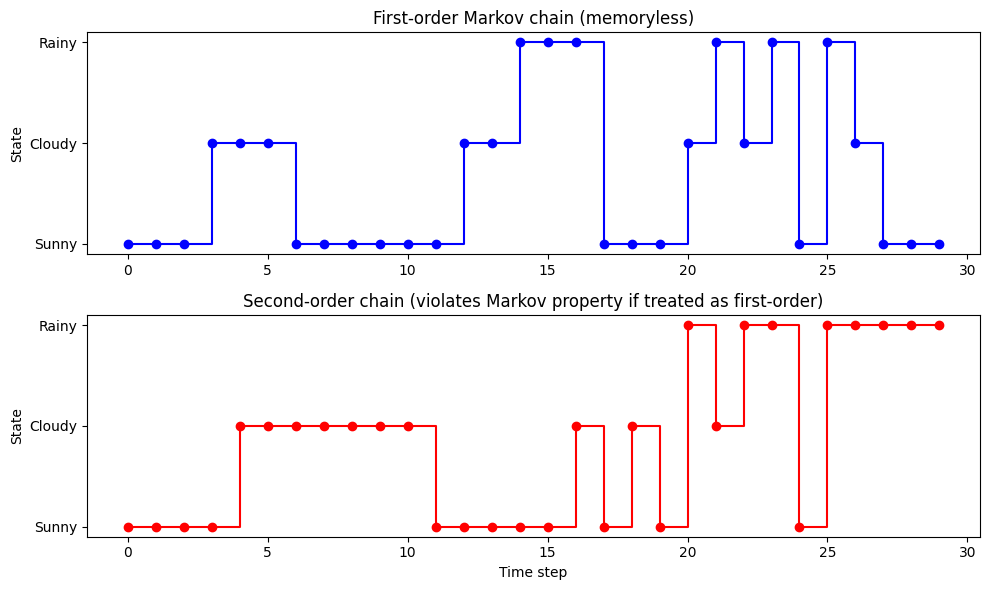

In [5]:
# ------------------------------------------------------------
# Demo: Show that first-order chain's next step depends only on current state
# ------------------------------------------------------------
np.random.seed(42)

# Generate a long chain
long_seq = generate_markov_chain(P, initial_state=0, n_steps=1000)

# Estimate P(s' | s) from the chain (should be close to P)
est_P = np.zeros((n_states, n_states))
for s in range(n_states):
    # find all indices where current state = s
    indices = [i for i, st in enumerate(long_seq[:-1]) if st == s]
    if indices:
        next_states = [long_seq[i+1] for i in indices]
        counts = Counter(next_states)
        for s_next in range(n_states):
            est_P[s, s_next] = counts[s_next] / len(indices)

print("Theoretical transition matrix (first-order):")
print(P.round(2))
print("\nEmpirical transition matrix from 1000 steps:")
print(est_P.round(2))

# Test Markov property: given current state, the next state distribution
# should be the same regardless of which previous state preceded it.
print("\n--- Testing Markov property ---")
for curr in range(n_states):
    # Gather transitions where current = curr, grouped by previous state
    groups = {prev: [] for prev in range(n_states)}
    for i in range(1, len(long_seq)-1):
        prev = long_seq[i-1]
        curr_state = long_seq[i]
        nxt = long_seq[i+1]
        if curr_state == curr:
            groups[prev].append(nxt)
    for prev, nxt_list in groups.items():
        if len(nxt_list) > 5:  # enough samples
            dist = np.bincount(nxt_list, minlength=n_states) / len(nxt_list)
            print(f"Current state = {states[curr]}, previous = {states[prev]}: next distribution = {dist.round(2)}")
    print("---")

# ------------------------------------------------------------
# Now show a second-order chain - the first-order approximation fails
# ------------------------------------------------------------
print("\nSecond-order chain (generated) - first-order approximation fails")
seq2 = generate_second_order(initial_pair=(0,0), n_steps=500)

# Estimate first-order transition matrix from this data
est_P2 = np.zeros((n_states, n_states))
for s in range(n_states):
    indices = [i for i, st in enumerate(seq2[:-1]) if st == s]
    if indices:
        next_states = [seq2[i+1] for i in indices]
        counts = Counter(next_states)
        for s_next in range(n_states):
            est_P2[s, s_next] = counts[s_next] / len(indices)

print("First-order matrix estimated from second-order data:")
print(est_P2.round(2))
print("\nBut these numbers hide the dependence on the previous state.")
print("Let's condition on the previous state as well:")

for prev in range(n_states):
    for curr in range(n_states):
        # find triples where (prev, curr) occur
        triples = []
        for i in range(2, len(seq2)):
            if seq2[i-2] == prev and seq2[i-1] == curr:
                triples.append(seq2[i])
        if len(triples) > 5:
            dist = np.bincount(triples, minlength=n_states) / len(triples)
            print(f"After ({states[prev]},{states[curr]}) -> next distribution = {dist.round(2)}")
        else:
            print(f"After ({states[prev]},{states[curr]}) -> insufficient data")

# ------------------------------------------------------------
# Visualisation of a sample path for both chains
# ------------------------------------------------------------
fig, axes = plt.subplots(2, 1, figsize=(10, 6))

first_seq = generate_markov_chain(P, initial_state=0, n_steps=30)
second_seq = generate_second_order(initial_pair=(0,0), n_steps=30)

axes[0].plot(first_seq, 'o-', color='blue', drawstyle='steps-post')
axes[0].set_title('First‑order Markov chain (memoryless)')
axes[0].set_ylabel('State')
axes[0].set_yticks([0,1,2])
axes[0].set_yticklabels(states)

axes[1].plot(second_seq, 'o-', color='red', drawstyle='steps-post')
axes[1].set_title('Second‑order chain (violates Markov property if treated as first‑order)')
axes[1].set_xlabel('Time step')
axes[1].set_ylabel('State')
axes[1].set_yticks([0,1,2])
axes[1].set_yticklabels(states)

plt.tight_layout()
plt.show()